# 📊 Exploratory Data Analysis (EDA) - Telco Customer Churn

**Цель**: Глубокий анализ данных для понимания паттернов оттока клиентов

**Датасет**: IBM Telco Customer Churn (Kaggle)

---

## Оглавление
1. Загрузка и первичный осмотр данных
2. Анализ пропущенных значений и типов данных
3. Статистический анализ
4. Анализ целевой переменной (Churn)
5. Univariate Analysis
6. Bivariate Analysis
7. Correlation Analysis
8. Выводы и рекомендации

In [1]:
# Загрузка данных
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f"✅ Данные загружены успешно")
print(f"📊 Размер датасета: {df.shape}")
print(f"📋 Количество строк: {df.shape[0]:,}")
print(f"📋 Количество колонок: {df.shape[1]}")

# Первый взгляд на данные
print("\n🔍 Первые 5 строк:")
display(df.head())

print("\n📐 Типы данных:")
print(df.dtypes)

print("\n📊 Базовая информация:")
print(df.info())

print("\n📈 Статистика по числовым признакам:")
display(df.describe())

NameError: name 'pd' is not defined

In [ ]:
# Проверка дубликатов
duplicates = df.duplicated().sum()
print(f"🔍 Количество дубликатов: {duplicates}")

# Проверка уникальности customerID
unique_customers = df['customerID'].nunique()
print(f"👥 Уникальных клиентов: {unique_customers} из {len(df)}")
print(f"✅ CustomerID уникальны: {unique_customers == len(df)}")

🔍 Количество дубликатов: 0
👥 Уникальных клиентов: 7043 из 7043
✅ CustomerID уникальны: True


### 💡 Insight: 
Обнаружены пустые значения в TotalCharges (записаны как пробелы). Это клиенты с tenure=0 (новые клиенты). Логично заменить на MonthlyCharges или удалить, т.к. их мало.

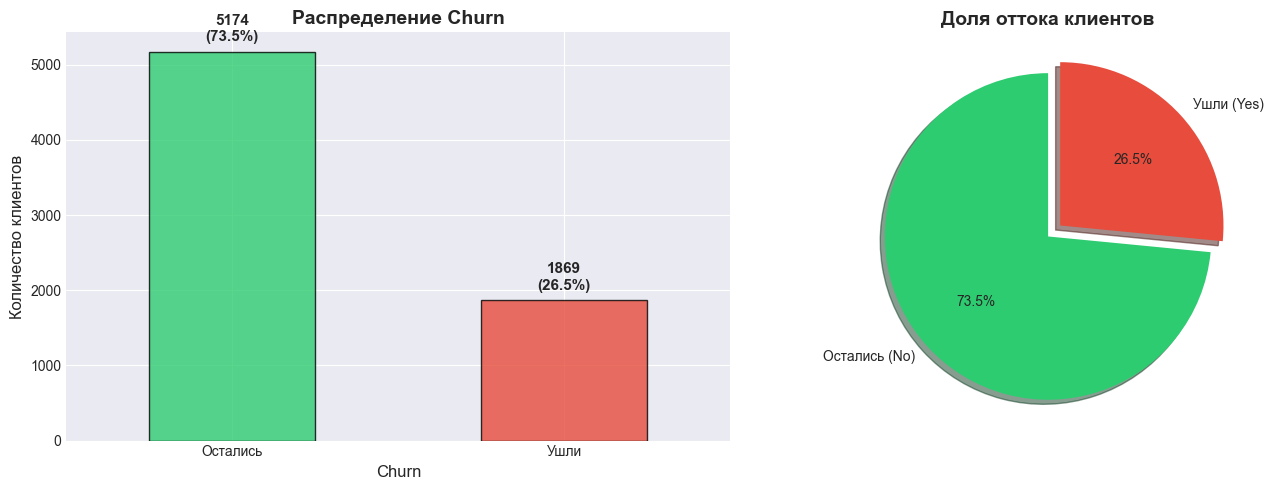

✅ График сохранен: reports/figures/churn_distribution.png


In [ ]:
# Визуализация целевой переменной
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
colors = ['#2ecc71', '#e74c3c']
churn_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black', alpha=0.8)
axes[0].set_title('Распределение Churn', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn', fontsize=12)
axes[0].set_ylabel('Количество клиентов', fontsize=12)
axes[0].set_xticklabels(['Остались', 'Ушли'], rotation=0)

# Добавляем значения на столбцы
for i, (count, pct) in enumerate(zip(churn_counts.values, churn_pct.values)):
    axes[0].text(i, count + 100, f'{count}\n({pct:.1f}%)', 
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values, labels=['Остались (No)', 'Ушли (Yes)'], 
           autopct='%1.1f%%', colors=colors, startangle=90,
           explode=(0, 0.1), shadow=True)
axes[1].set_title('Доля оттока клиентов', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/churn_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ График сохранен: reports/figures/churn_distribution.png")

In [ ]:
# Статистический анализ числовых признаков
for col in numeric_features:
    print(f"\n{'='*60}")
    print(f"📊 Статистика для {col}:")
    print(f"{'='*60}")
    print(f"Mean:     {df[col].mean():.2f}")
    print(f"Median:   {df[col].median():.2f}")
    print(f"Std:      {df[col].std():.2f}")
    print(f"Min:      {df[col].min():.2f}")
    print(f"Max:      {df[col].max():.2f}")
    print(f"Skewness: {df[col].skew():.2f}")
    
    # Проверка на выбросы (IQR метод)
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))).sum()
    print(f"Outliers: {outliers} ({(outliers/len(df)*100):.2f}%)")


📊 Статистика для tenure:
Mean:     32.37
Median:   29.00
Std:      24.56
Min:      0.00
Max:      72.00
Skewness: 0.24
Outliers: 0 (0.00%)

📊 Статистика для MonthlyCharges:
Mean:     64.76
Median:   70.35
Std:      30.09
Min:      18.25
Max:      118.75
Skewness: -0.22
Outliers: 0 (0.00%)


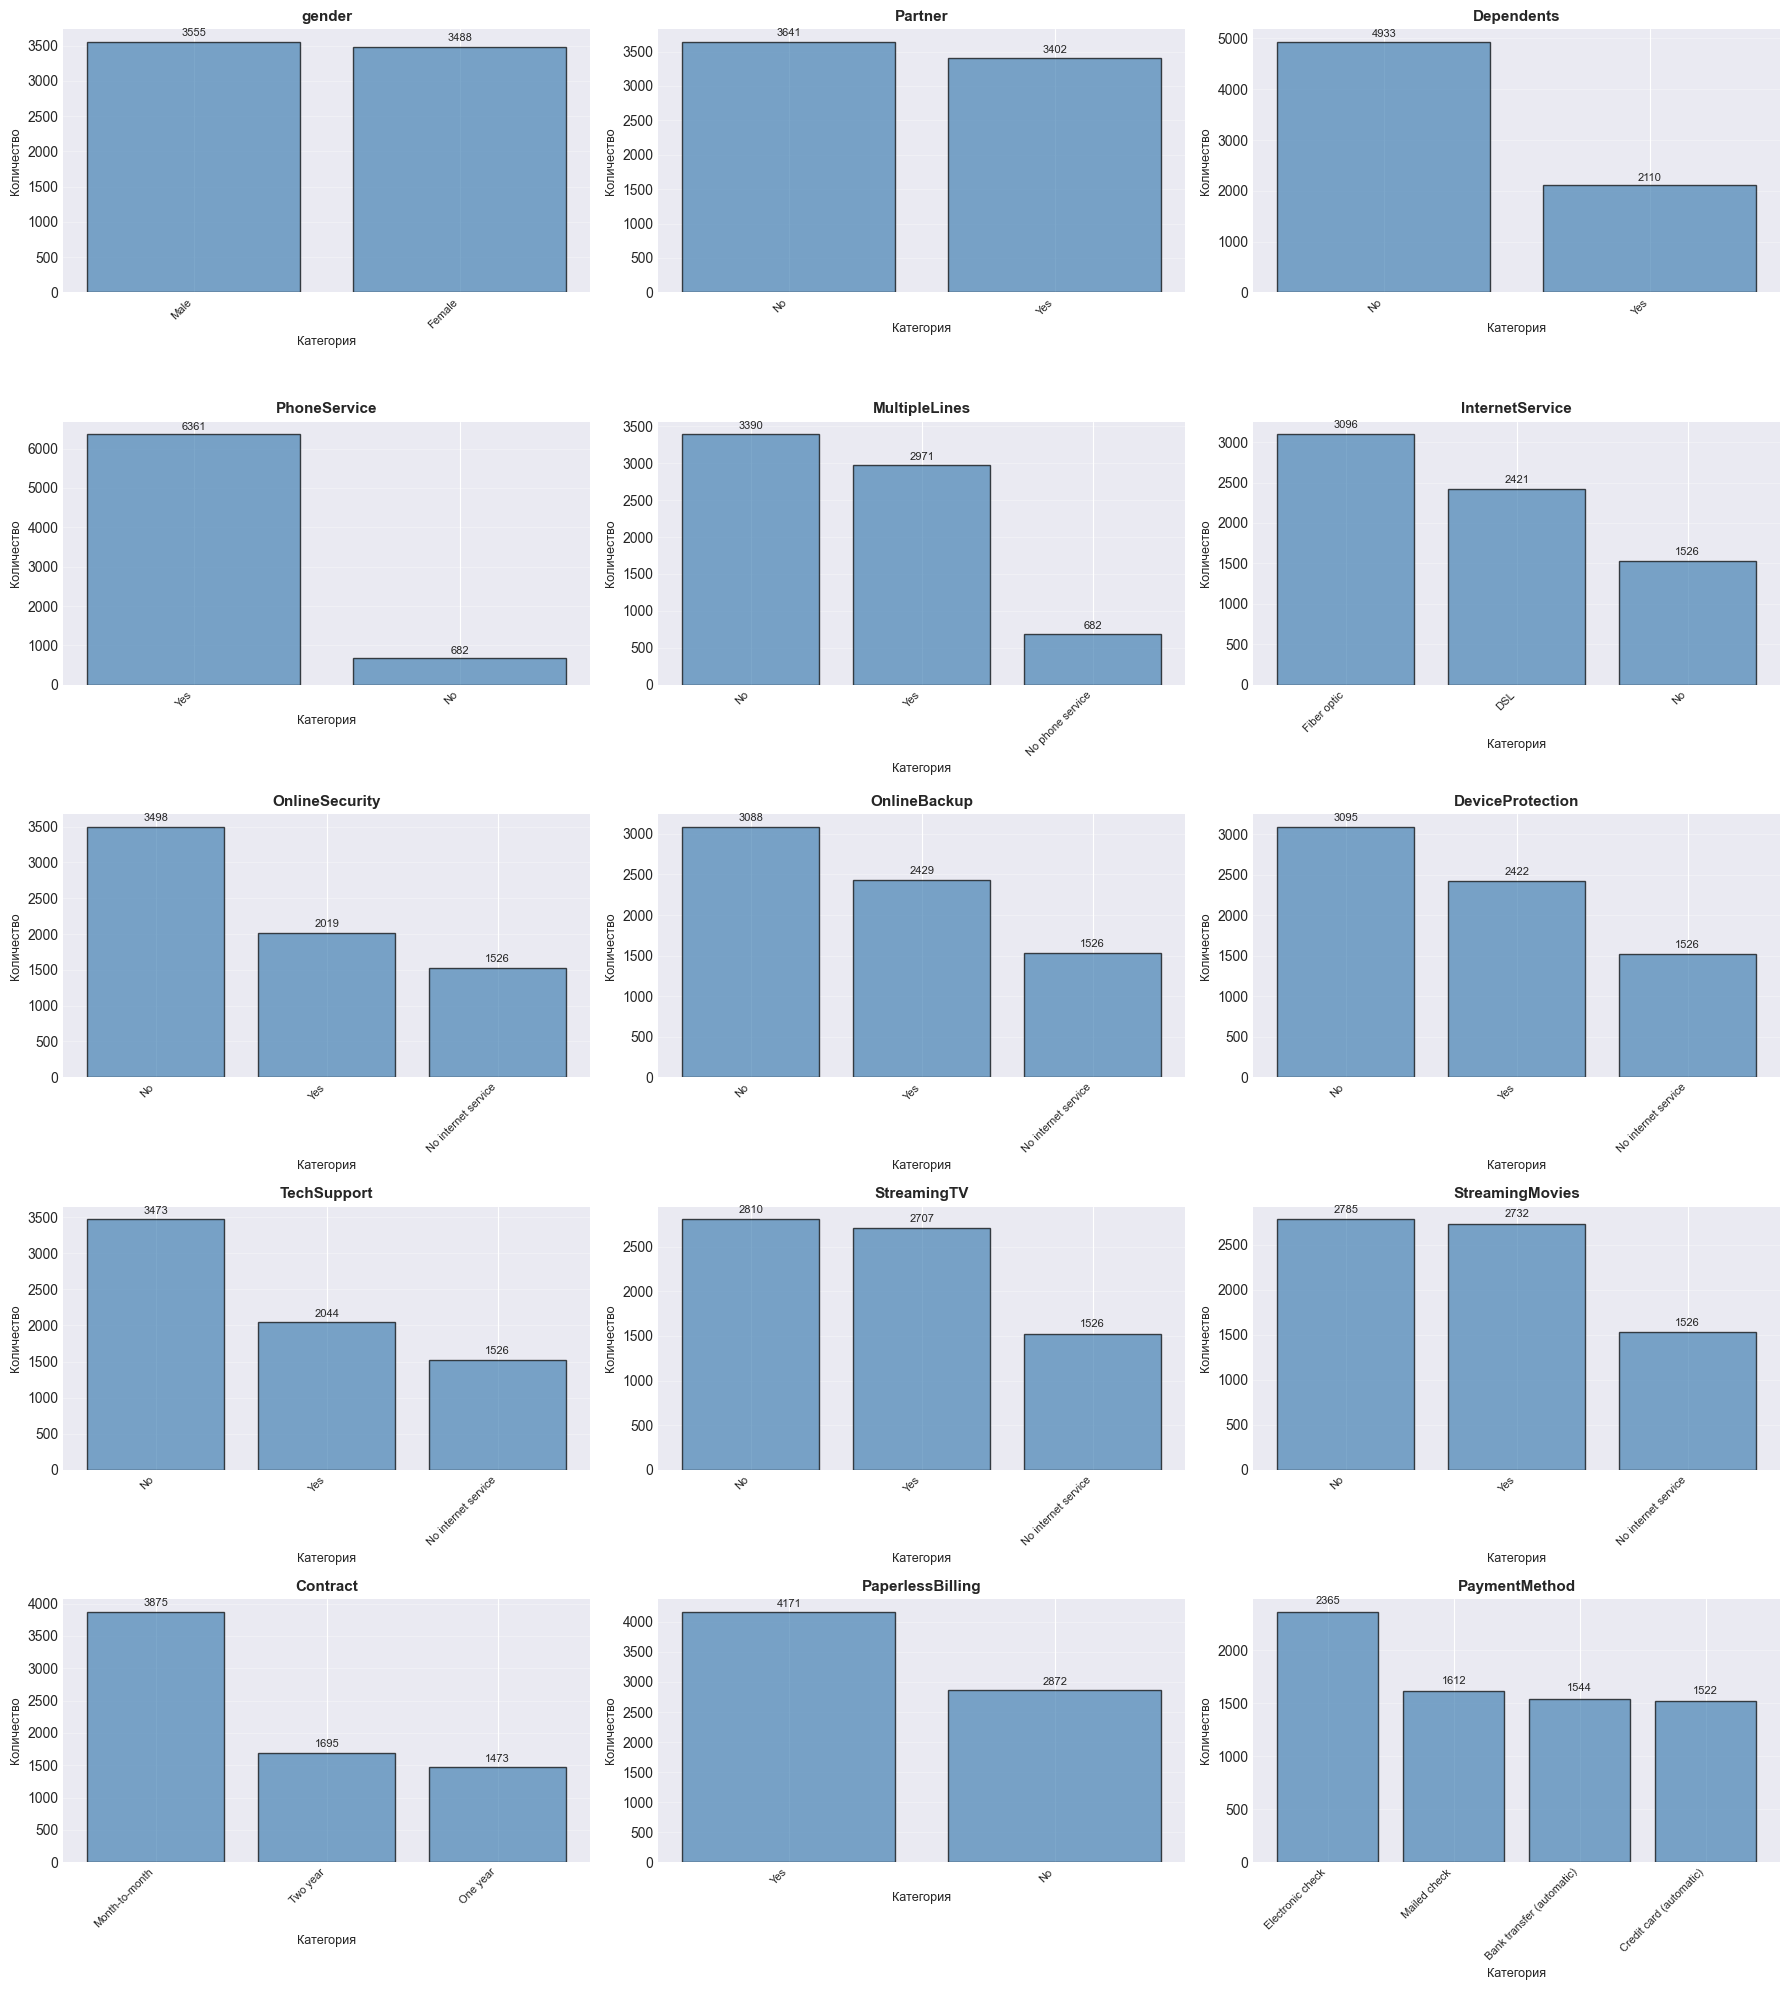

✅ График сохранен: reports/figures/categorical_distributions.png


In [ ]:
# Визуализация топ-10 категориальных признаков
fig, axes = plt.subplots(5, 3, figsize=(18, 20))
axes = axes.ravel()

for idx, col in enumerate(categorical_features[:15]):
    value_counts = df[col].value_counts()
    axes[idx].bar(range(len(value_counts)), value_counts.values, 
                  color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{col}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Категория', fontsize=9)
    axes[idx].set_ylabel('Количество', fontsize=9)
    axes[idx].set_xticks(range(len(value_counts)))
    axes[idx].set_xticklabels(value_counts.index, rotation=45, ha='right', fontsize=8)
    
    # Добавляем значения на столбцы
    for i, v in enumerate(value_counts.values):
        axes[idx].text(i, v + 50, str(v), ha='center', va='bottom', fontsize=8)
    
    axes[idx].grid(alpha=0.3, axis='y')

# Скрываем лишние subplot'ы
for idx in range(len(categorical_features), 15):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('../reports/figures/categorical_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ График сохранен: reports/figures/categorical_distributions.png")

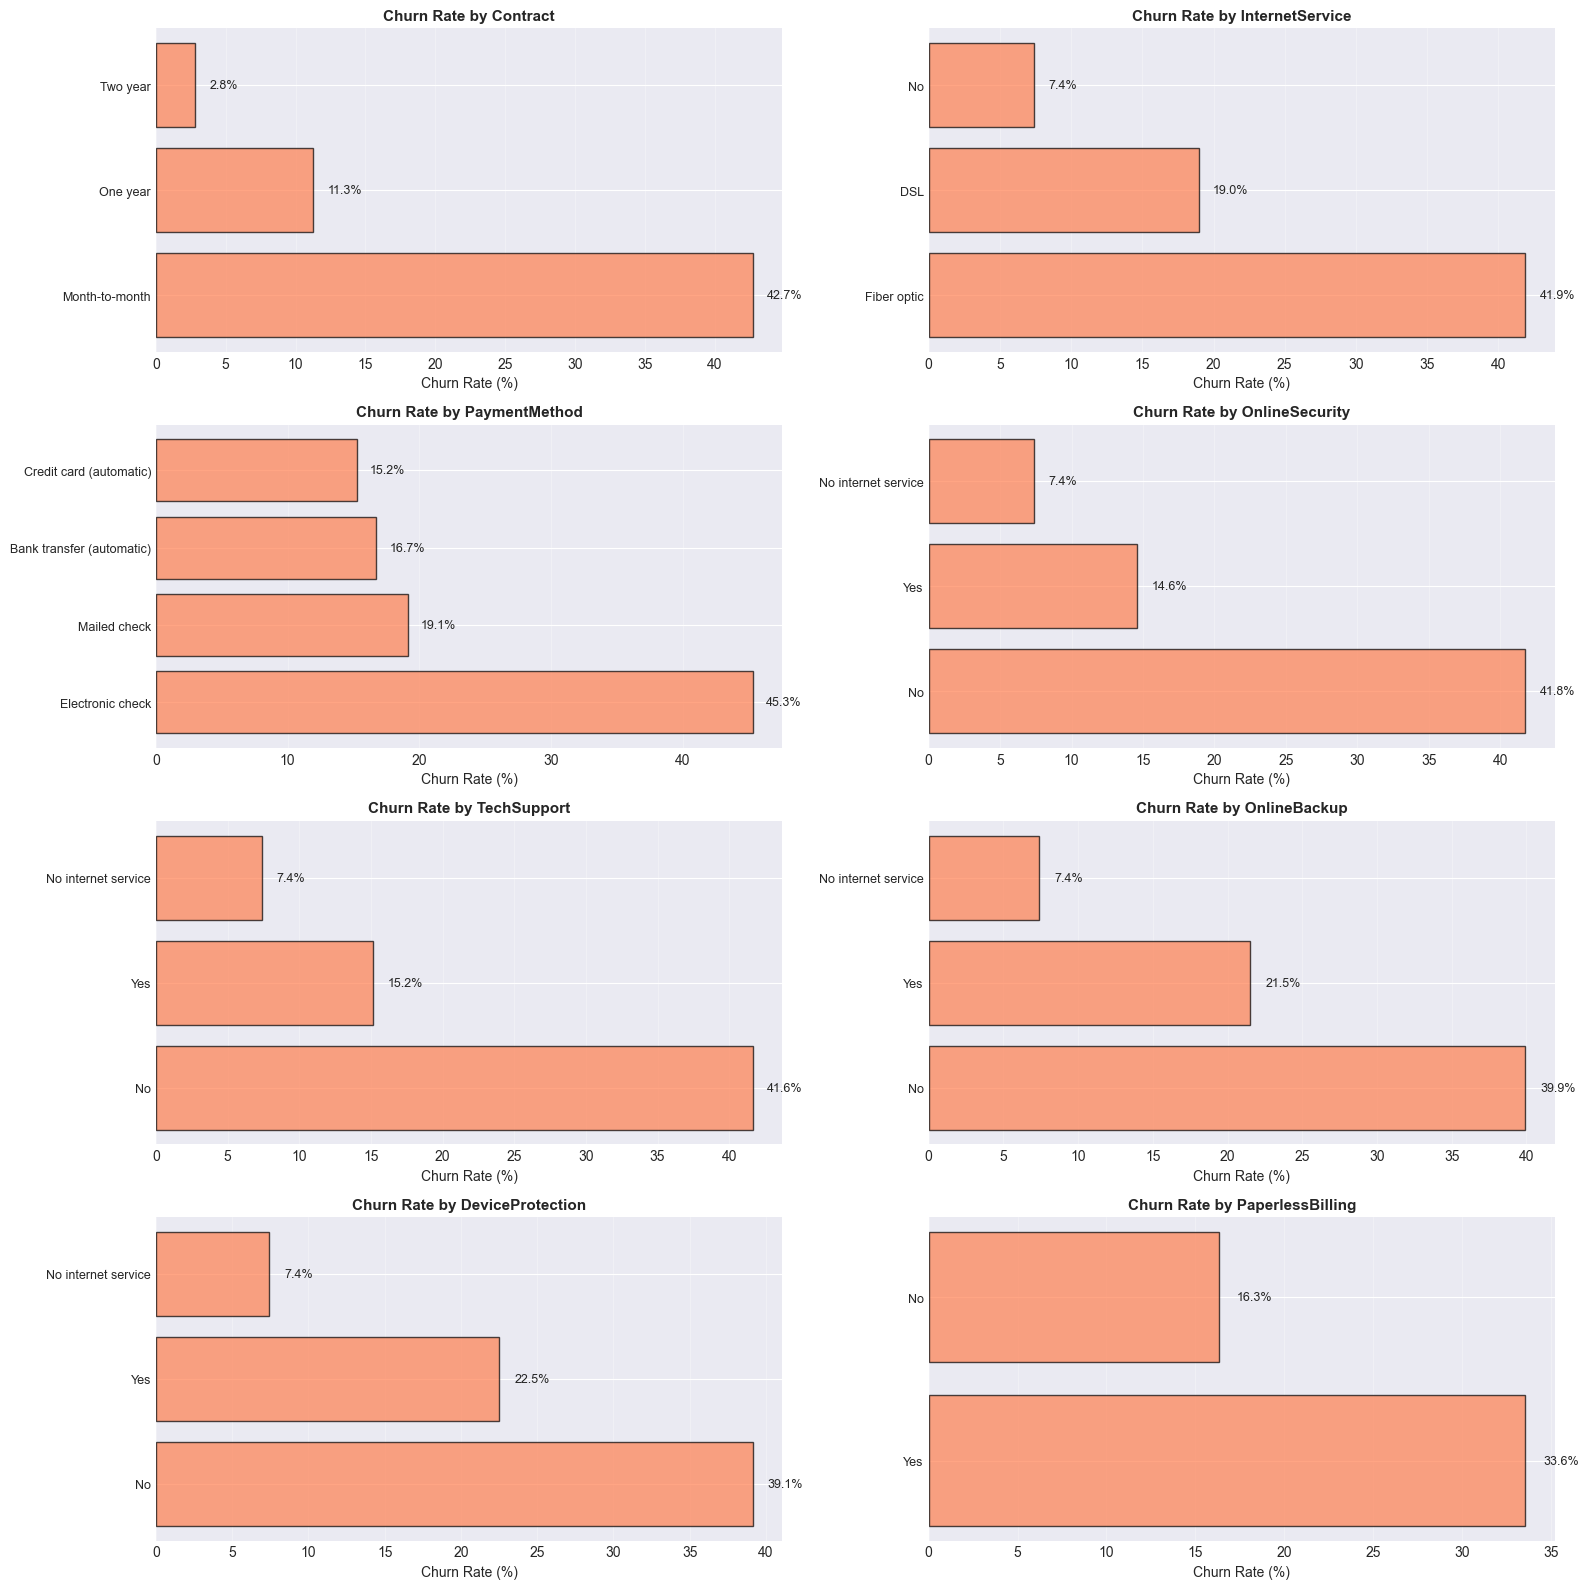

✅ График сохранен: reports/figures/churn_rate_by_categories.png


In [ ]:
# Churn rate для категориальных признаков (топ-10 важных)
important_cats = ['Contract', 'InternetService', 'PaymentMethod', 'OnlineSecurity', 
                  'TechSupport', 'OnlineBackup', 'DeviceProtection', 'PaperlessBilling']

fig, axes = plt.subplots(4, 2, figsize=(16, 16))
axes = axes.ravel()

for idx, col in enumerate(important_cats):
    # Подсчет Churn rate
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').sum() / len(x) * 100).sort_values(ascending=False)
    
    axes[idx].barh(range(len(churn_rate)), churn_rate.values, color='coral', edgecolor='black', alpha=0.7)
    axes[idx].set_yticks(range(len(churn_rate)))
    axes[idx].set_yticklabels(churn_rate.index, fontsize=9)
    axes[idx].set_xlabel('Churn Rate (%)', fontsize=10)
    axes[idx].set_title(f'Churn Rate by {col}', fontsize=11, fontweight='bold')
    axes[idx].grid(alpha=0.3, axis='x')
    
    # Добавляем значения
    for i, v in enumerate(churn_rate.values):
        axes[idx].text(v + 1, i, f'{v:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/figures/churn_rate_by_categories.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ График сохранен: reports/figures/churn_rate_by_categories.png")

In [ ]:
# Топ корреляций с Churn
churn_corr = correlation_matrix['Churn_numeric'].sort_values(ascending=False)
print("🎯 Топ корреляций с Churn:")
print("="*60)
print(churn_corr)

🎯 Топ корреляций с Churn:
Churn_numeric               1.000000
MonthlyCharges              0.193356
PaperlessBilling_numeric    0.191825
SeniorCitizen               0.150889
PhoneService_numeric        0.011942
gender_numeric             -0.008612
Partner_numeric            -0.150448
Dependents_numeric         -0.164221
tenure                     -0.352229
Name: Churn_numeric, dtype: float64


---
## ✅ EDA Complete!

**Следующие шаги**:
1. Data Preprocessing (02_preprocessing_modeling.ipynb)
2. Feature Engineering
3. Model Training & Selection
4. Model Evaluation & Explainability

## 9. Ключевые выводы и инсайты

### 🔍 Основные находки:

1. **Дисбаланс классов**: 73.5% остались, 26.5% ушли → потребуется балансировка
2. **TotalCharges**: имеет скрытые пропуски (пробелы), нужна очистка
3. **Tenure**: сильный индикатор - клиенты с малым сроком чаще уходят
4. **Contract**: Month-to-month контракты имеют самый высокий churn rate
5. **InternetService**: Fiber optic клиенты чаще уходят
6. **Payment Method**: Electronic check связан с высоким churn
7. **Senior Citizens**: имеют несколько повышенный churn rate

### 📈 Рекомендации для бизнеса:
- Фокус на удержание клиентов с month-to-month контрактами
- Улучшить качество Fiber optic сервиса
- Предложить бонусы клиентам в первые месяцы
- Стимулировать переход на долгосрочные контракты

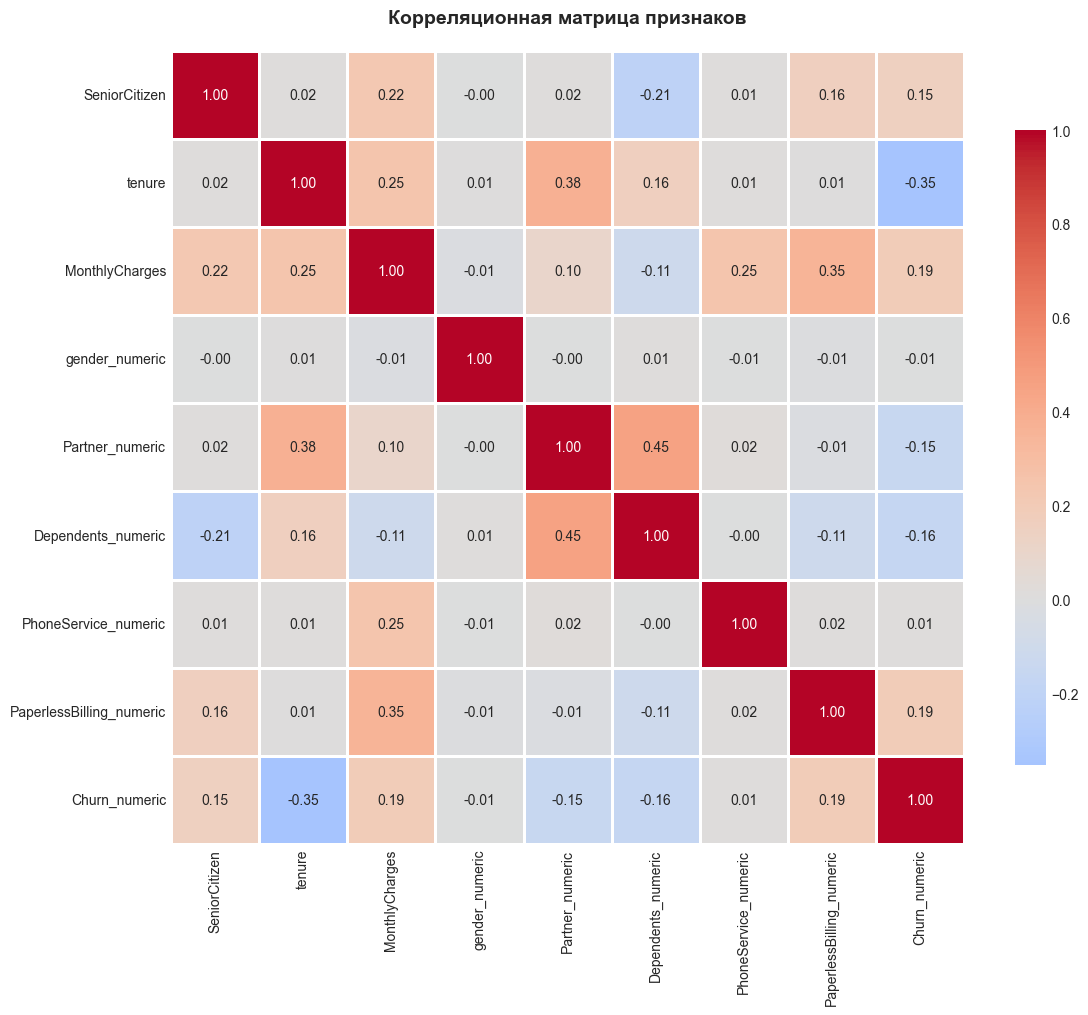

✅ График сохранен: reports/figures/correlation_matrix.png


In [ ]:
# Визуализация корреляционной матрицы
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Корреляционная матрица признаков', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../reports/figures/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ График сохранен: reports/figures/correlation_matrix.png")

In [ ]:
# Создаем копию датасета для корреляционного анализа
df_corr = df.copy()

# Преобразуем Churn в числовой формат
df_corr['Churn_numeric'] = (df_corr['Churn'] == 'Yes').astype(int)

# Преобразуем SeniorCitizen уже числовой
# Добавляем числовые версии важных категориальных признаков
df_corr['gender_numeric'] = (df_corr['gender'] == 'Male').astype(int)
df_corr['Partner_numeric'] = (df_corr['Partner'] == 'Yes').astype(int)
df_corr['Dependents_numeric'] = (df_corr['Dependents'] == 'Yes').astype(int)
df_corr['PhoneService_numeric'] = (df_corr['PhoneService'] == 'Yes').astype(int)
df_corr['PaperlessBilling_numeric'] = (df_corr['PaperlessBilling'] == 'Yes').astype(int)

# Выбираем только числовые колонки
numeric_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 
                'gender_numeric', 'Partner_numeric', 'Dependents_numeric',
                'PhoneService_numeric', 'PaperlessBilling_numeric', 'Churn_numeric']

correlation_matrix = df_corr[numeric_cols].corr()

print("📊 Матрица корреляции создана")

📊 Матрица корреляции создана


## 8. Correlation Analysis

In [ ]:
# Статистика Churn для числовых признаков
for col in numeric_features:
    print(f"\n{'='*60}")
    print(f"📊 {col} vs Churn:")
    print(f"{'='*60}")
    grouped = df.groupby('Churn')[col].agg(['mean', 'median', 'std'])
    print(grouped)
    
    # Разница в среднем
    diff = grouped.loc['Yes', 'mean'] - grouped.loc['No', 'mean']
    pct_diff = (diff / grouped.loc['No', 'mean']) * 100
    print(f"\nРазница в среднем: {diff:.2f} ({pct_diff:+.2f}%)")


📊 tenure vs Churn:
            mean  median        std
Churn                              
No     37.569965    38.0  24.113777
Yes    17.979133    10.0  19.531123

Разница в среднем: -19.59 (-52.14%)

📊 MonthlyCharges vs Churn:
            mean  median        std
Churn                              
No     61.265124  64.425  31.092648
Yes    74.441332  79.650  24.666053

Разница в среднем: 13.18 (+21.51%)


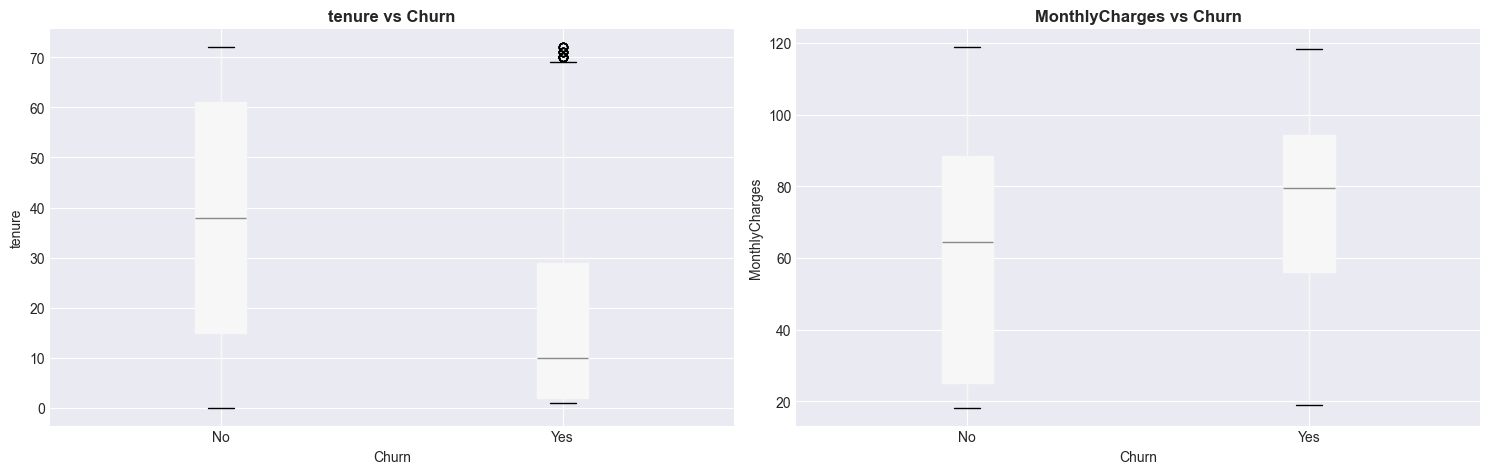

✅ График сохранен: reports/figures/churn_vs_numeric.png


In [ ]:
# Churn vs Числовые признаки
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for idx, col in enumerate(numeric_features):
    df.boxplot(column=col, by='Churn', ax=axes[idx], patch_artist=True)
    axes[idx].set_title(f'{col} vs Churn', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Churn', fontsize=10)
    axes[idx].set_ylabel(col, fontsize=10)
    plt.sca(axes[idx])
    plt.xticks([1, 2], ['No', 'Yes'])

plt.suptitle('')  # Убираем автоматический заголовок
plt.tight_layout()
plt.savefig('../reports/figures/churn_vs_numeric.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ График сохранен: reports/figures/churn_vs_numeric.png")

## 7. Bivariate Analysis - Churn vs Features

In [ ]:
# Анализ категориальных признаков
print("📋 Уникальные значения в категориальных признаках:\n")
for col in categorical_features:
    unique_count = df[col].nunique()
    print(f"{col:20} : {unique_count:2} уникальных значений")
    print(f"  → {df[col].unique().tolist()}")
    print()

📋 Уникальные значения в категориальных признаках:

gender               :  2 уникальных значений
  → ['Female', 'Male']

Partner              :  2 уникальных значений
  → ['Yes', 'No']

Dependents           :  2 уникальных значений
  → ['No', 'Yes']

PhoneService         :  2 уникальных значений
  → ['No', 'Yes']

MultipleLines        :  3 уникальных значений
  → ['No phone service', 'No', 'Yes']

InternetService      :  3 уникальных значений
  → ['DSL', 'Fiber optic', 'No']

OnlineSecurity       :  3 уникальных значений
  → ['No', 'Yes', 'No internet service']

OnlineBackup         :  3 уникальных значений
  → ['Yes', 'No', 'No internet service']

DeviceProtection     :  3 уникальных значений
  → ['No', 'Yes', 'No internet service']

TechSupport          :  3 уникальных значений
  → ['No', 'Yes', 'No internet service']

StreamingTV          :  3 уникальных значений
  → ['No', 'Yes', 'No internet service']

StreamingMovies      :  3 уникальных значений
  → ['No', 'Yes', 'No internet se

## 6. Univariate Analysis - Категориальные признаки

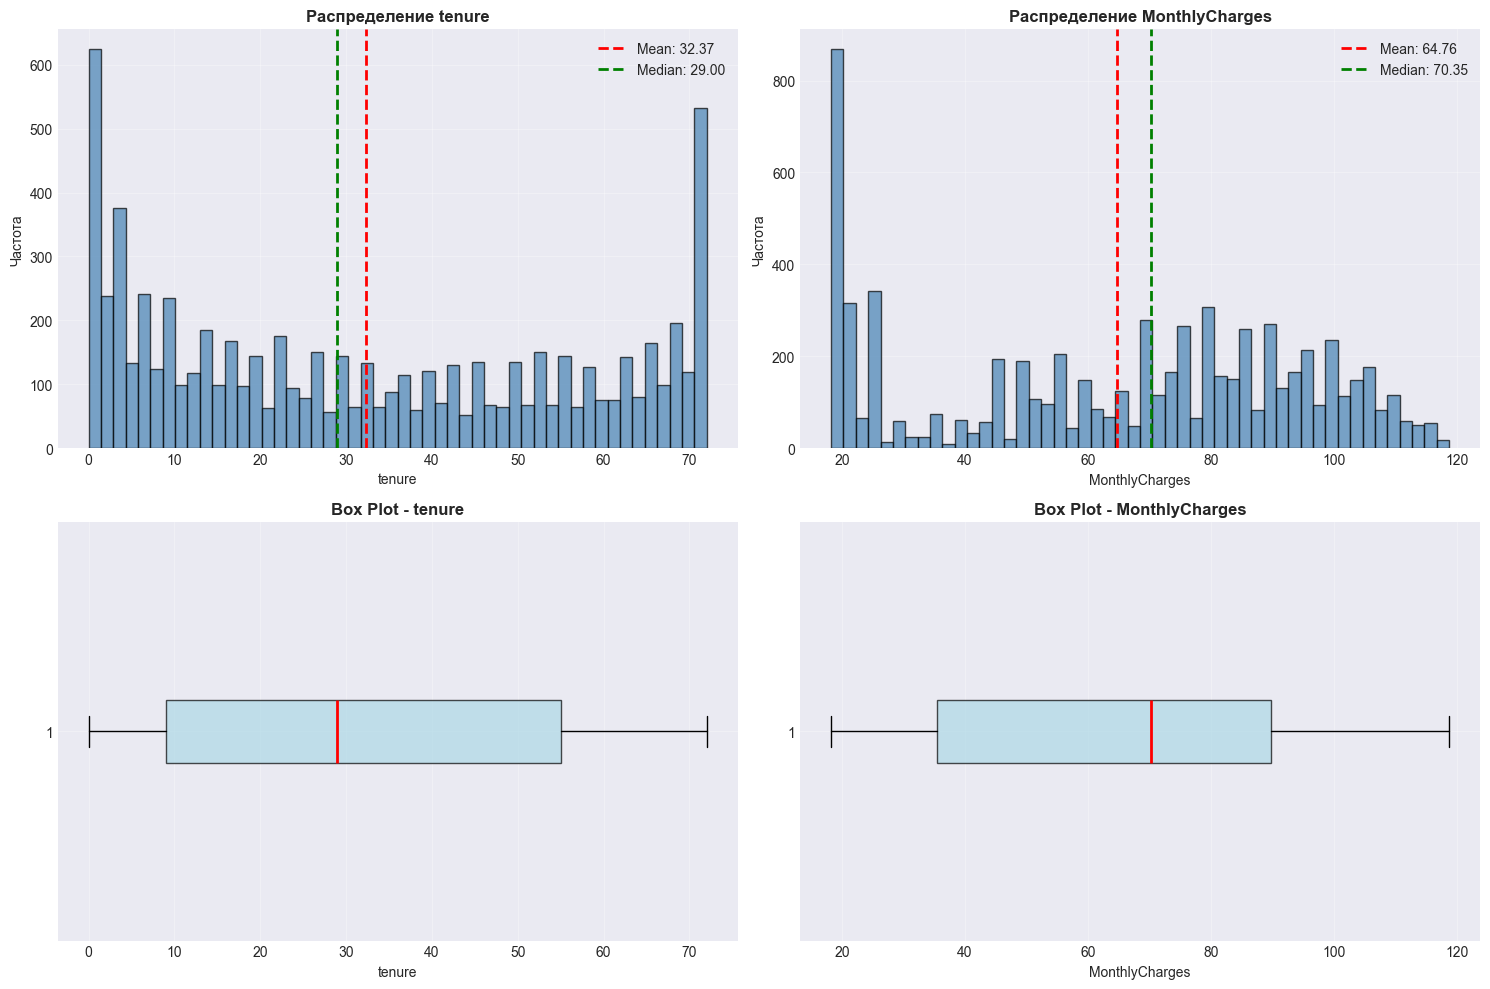

✅ График сохранен: reports/figures/numeric_distributions.png


In [ ]:
# Распределение числовых признаков
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(numeric_features):
    # Histogram
    axes[idx].hist(df[col], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[idx].set_title(f'Распределение {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col, fontsize=10)
    axes[idx].set_ylabel('Частота', fontsize=10)
    axes[idx].axvline(df[col].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df[col].mean():.2f}')
    axes[idx].axvline(df[col].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df[col].median():.2f}')
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)
    
    # Box plot
    axes[idx + 2].boxplot(df[col], vert=False, patch_artist=True,
                          boxprops=dict(facecolor='lightblue', alpha=0.7),
                          medianprops=dict(color='red', linewidth=2))
    axes[idx + 2].set_title(f'Box Plot - {col}', fontsize=12, fontweight='bold')
    axes[idx + 2].set_xlabel(col, fontsize=10)
    axes[idx + 2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/numeric_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ График сохранен: reports/figures/numeric_distributions.png")

In [ ]:
# Определяем числовые и категориальные признаки
numeric_features = ['tenure', 'MonthlyCharges']  # TotalCharges обработаем позже
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
categorical_features.remove('customerID')  # Удаляем ID
categorical_features.remove('Churn')  # Удаляем target

print(f"📊 Числовых признаков: {len(numeric_features)}")
print(f"📋 Категориальных признаков: {len(categorical_features)}")
print(f"\n Числовые: {numeric_features}")
print(f"📋 Категориальные: {categorical_features}")

📊 Числовых признаков: 2
📋 Категориальных признаков: 16

 Числовые: ['tenure', 'MonthlyCharges']
📋 Категориальные: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges']


## 5. Univariate Analysis - Числовые признаки

In [ ]:
# Распределение целевой переменной
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print("🎯 Распределение целевой переменной Churn:")
print("="*60)
for label, count, pct in zip(churn_counts.index, churn_counts.values, churn_pct.values):
    print(f"{label:5}: {count:5} ({pct:5.2f}%)")

print(f"\n⚖️ Соотношение классов: 1:{churn_counts['No']/churn_counts['Yes']:.2f}")
print(f"⚠️ Дисбаланс классов: {'Да' if churn_pct['No'] > 60 else 'Нет'}")

🎯 Распределение целевой переменной Churn:
No   :  5174 (73.46%)
Yes  :  1869 (26.54%)

⚖️ Соотношение классов: 1:2.77
⚠️ Дисбаланс классов: Да


## 4. Анализ целевой переменной (Churn)

In [ ]:
# Обнаружение скрытых пропусков в TotalCharges (пробелы)
whitespace_mask = df['TotalCharges'].str.strip() == ''
print(f"🔍 Найдено пустых значений (пробелов) в TotalCharges: {whitespace_mask.sum()}")

if whitespace_mask.sum() > 0:
    print("\n📋 Примеры записей с пустыми TotalCharges:")
    print(df[whitespace_mask][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].head(10))
    
    # Анализ паттернов
    print(f"\n📊 Статистика записей с пустыми TotalCharges:")
    print(f"Средний tenure: {df[whitespace_mask]['tenure'].mean():.2f}")
    print(f"Средний MonthlyCharges: {df[whitespace_mask]['MonthlyCharges'].mean():.2f}")

🔍 Найдено пустых значений (пробелов) в TotalCharges: 11

📋 Примеры записей с пустыми TotalCharges:
      customerID  tenure  MonthlyCharges TotalCharges Churn
488   4472-LVYGI       0           52.55                 No
753   3115-CZMZD       0           20.25                 No
936   5709-LVOEQ       0           80.85                 No
1082  4367-NUYAO       0           25.75                 No
1340  1371-DWPAZ       0           56.05                 No
3331  7644-OMVMY       0           19.85                 No
3826  3213-VVOLG       0           25.35                 No
4380  2520-SGTTA       0           20.00                 No
5218  2923-ARZLG       0           19.70                 No
6670  4075-WKNIU       0           73.35                 No

📊 Статистика записей с пустыми TotalCharges:
Средний tenure: 0.00
Средний MonthlyCharges: 41.42


In [ ]:
# Проверка пропущенных значений
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing[missing > 0],
    'Percentage': missing_pct[missing > 0]
}).sort_values('Missing Count', ascending=False)

if len(missing_df) > 0:
    print("⚠️ Обнаружены пропущенные значения:")
    print(missing_df)
else:
    print("✅ Пропущенных значений не обнаружено")

# Проверка TotalCharges (object вместо float)
print(f"\n🔍 Проверка TotalCharges:")
print(f"Тип данных: {df['TotalCharges'].dtype}")
print(f"Примеры значений: {df['TotalCharges'].head(10).tolist()}")

✅ Пропущенных значений не обнаружено

🔍 Проверка TotalCharges:
Тип данных: object
Примеры значений: ['29.85', '1889.5', '108.15', '1840.75', '151.65', '820.5', '1949.4', '301.9', '3046.05', '3487.95']


## 3. Анализ пропущенных значений и аномалий

In [ ]:
# Статистика числовых признаков
print("📊 Статистика числовых признаков:")
print("="*60)
df.describe().T

📊 Статистика числовых признаков:


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [ ]:
# Информация о датасете
print("📋 Информация о типах данных и памяти:")
print("="*60)
df.info()

📋 Информация о типах данных и памяти:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Pape

## 2. Первичный осмотр данных

In [ ]:
# Загрузка датасета
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f"📦 Датасет загружен успешно!")
print(f"📊 Размерность: {df.shape[0]} строк, {df.shape[1]} колонок")
print(f"\n{'='*60}")
df.head()

📦 Датасет загружен успешно!
📊 Размерность: 7043 строк, 21 колонок



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Загрузка библиотек и данных